In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [6]:
data = pd.read_csv("loan approval data.csv")
data.head()
data.info()
data.isnull().sum()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


### >>> Handling Missing Values

In [ ]:
categorical_cols = data.select_dtypes(include=['object']).columns
# numerical_cols = data.select_dtypes(include=['float64']).columns
numerical_cols = data.select_dtypes(include=['number']).columns

categorical_cols
numerical_cols

categorical_cols.size + numerical_cols.size

20

In [14]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
# num_imputer.fit_transform(data[numerical_cols])
data[numerical_cols] = num_imputer.fit_transform(data[numerical_cols])  #to make changes in final dataset

cat_imputer = SimpleImputer(strategy='most_frequent')
data[categorical_cols] = cat_imputer.fit_transform(data[categorical_cols])  #to make changes in final dataset

data.head()
data.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

### >>> EDA - Exploratory Data Analysis
##### To find the relation between the features - How and which features are more imp. to contribute in predicting the output.

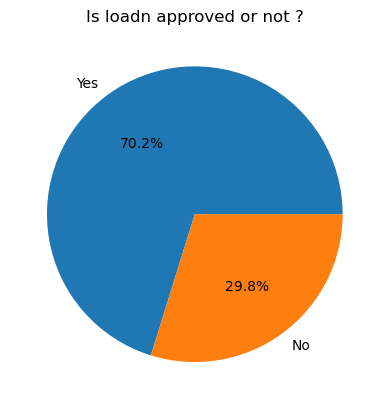

In [15]:
# How balanced our classes are ?

classes_count = data["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["Yes", "No"], autopct='%1.1f%%')
plt.title("Is loadn approved or not ?")
plt.show()


[Text(0, 0, '621'), Text(0, 0, '379')]

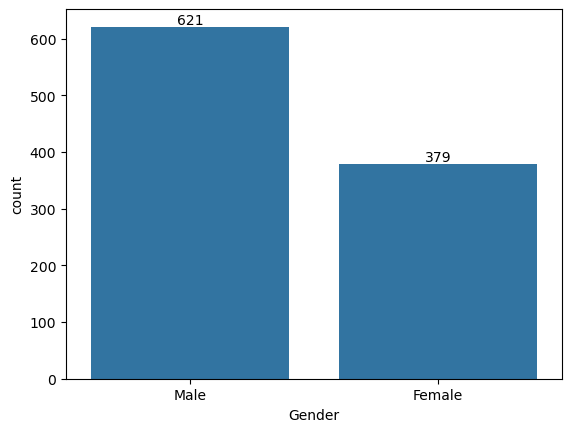

In [17]:
# analyze gender categories

gender_cnt = data["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])


[Text(0, 0, '722'), Text(0, 0, '278')]

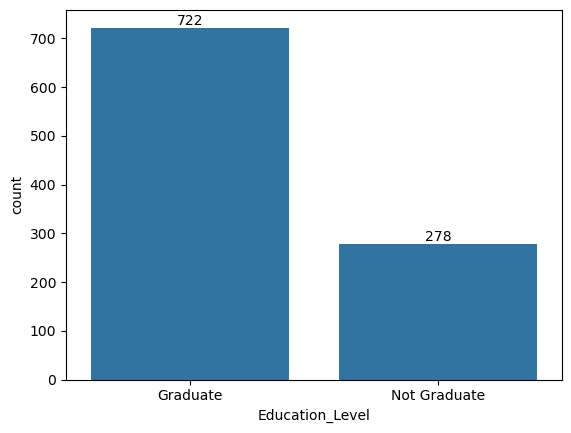

In [20]:
# Analyze the education level of the applicants

edu_cnt = data["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])


<Axes: xlabel='Applicant_Income', ylabel='Count'>

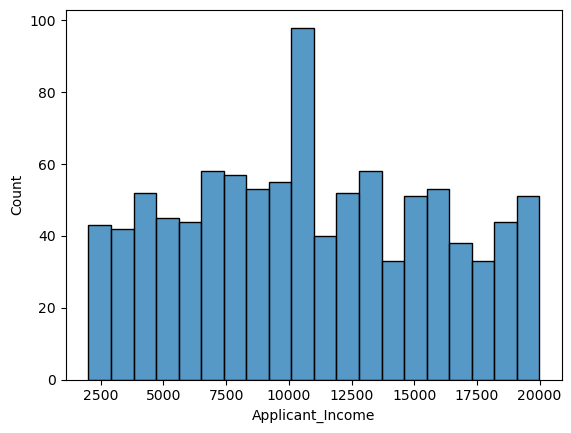

In [23]:
#Analyze income
sns.histplot(
    data = data,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

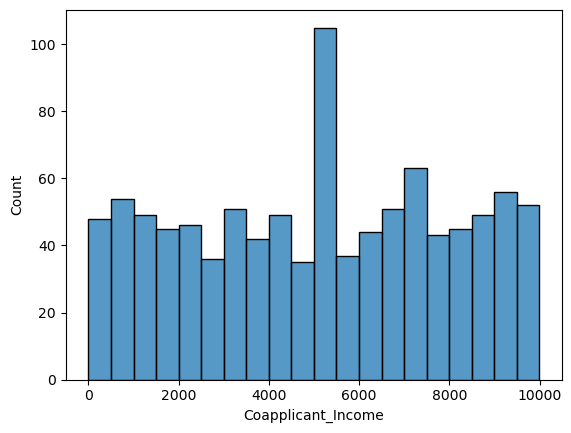

In [24]:
#Analyze income
sns.histplot(
    data = data,
    x = "Coapplicant_Income",
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

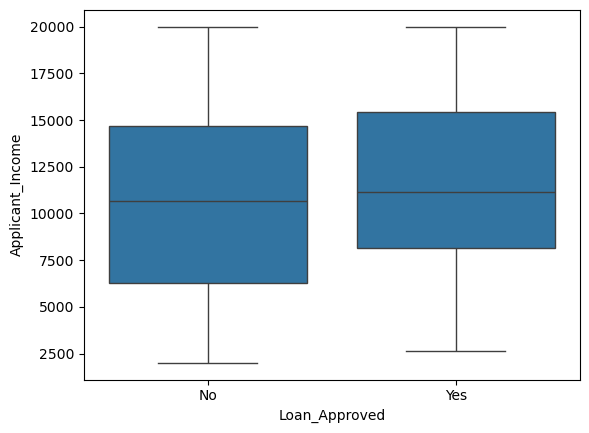

In [26]:
# Outllier - box plots

sns.boxplot(
    data = data,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

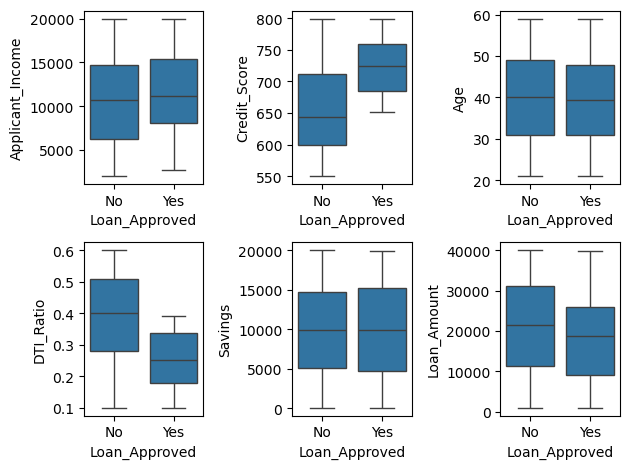

In [32]:
fig, axes= plt.subplots(2,3)

sns.boxplot(ax=axes[0,0], data = data, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax=axes[0,1], data = data, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax=axes[1,0], data = data, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax=axes[1,1], data = data, x = "Loan_Approved", y = "Savings")
sns.boxplot(ax=axes[0,2], data = data, x = "Loan_Approved", y = "Age")
sns.boxplot(ax=axes[1,2], data = data, x = "Loan_Approved", y = "Loan_Amount")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

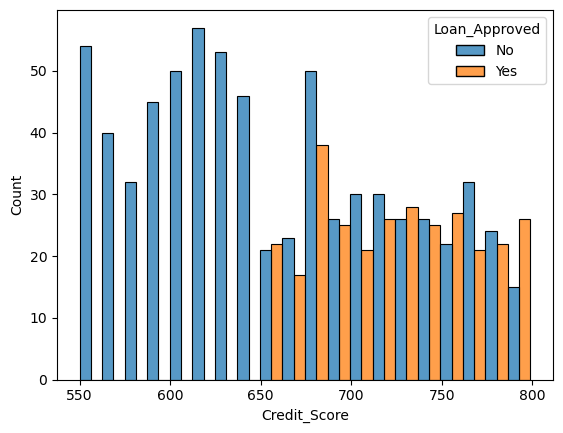

In [36]:
# Credit Score with Loan Approved

#Analyze income
sns.histplot(
    data = data,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)  


<Axes: xlabel='Applicant_Income', ylabel='Count'>

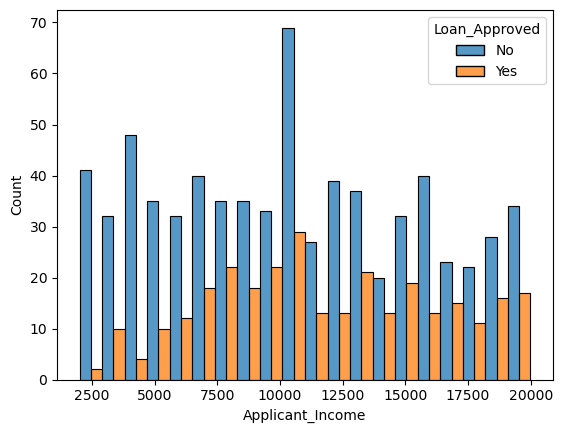

In [38]:
# Applicant Income with Loan Approved

#Analyze income
sns.histplot(
    data = data,
    x = "Applicant_Income",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)  


In [41]:
# Removing Applicant Id
data = data.drop("Applicant_ID", axis=1)
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
